# 04 — Baseline Validation

**Goal:** Validate that composite novelty scores correctly separate NOVEL papers from SKG papers.

This replaces the abandoned supervised classifier — dropped due to temporal leakage (SciND labels perfectly correlate with publication year, making classification trivial and meaningless).

**Pass condition:** NOVEL papers should score significantly higher than SKG on composite novelty.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

FEATURE_MATRIX = "../../outputs/final/novelty_feature_matrix_with_score.csv"
PAPER_NODES    = "../../outputs/final/paper_nodes.csv"
OUT_DIR        = "../../outputs/final/"

In [2]:
# Load and merge
fm = pd.read_csv(FEATURE_MATRIX)
pn = pd.read_csv(PAPER_NODES)[['node_id', 'split', 'domain']]
pn = pn.rename(columns={'node_id': 'paper_id'})

df = fm.merge(pn, on='paper_id', how='left')
df = df[df['split'].isin(['NOVEL', 'SKG'])].copy()

print(f"Total papers in analysis: {len(df)}")
print(df['split'].value_counts())
print()
print("Composite novelty by split:")
print(df.groupby('split')['composite_novelty'].describe().round(4))

Total papers in analysis: 3678
split
SKG      2916
NOVEL     762
Name: count, dtype: int64

Composite novelty by split:
        count    mean     std     min     25%     50%     75%     max
split                                                                
NOVEL   762.0  0.7255  0.1052  0.1844  0.6489  0.7592  0.7986  0.9106
SKG    2916.0  0.7594  0.0835  0.1652  0.7459  0.7808  0.8032  0.9612


In [3]:
df

,paper_id,year,semantic_knn,structural_novelty,triple_count,cited_by_count,reference_count,citation_signal,struct_norm,semantic_norm,citation_norm,composite_novelty,split,domain
0,SKG_MT_1151,2010,1.000000,1.0,70.0,3,17,1.386294,1.0,1.000000,0.149105,0.914911,SKG,MT
1,SKG_SUM_67,2010,1.000000,1.0,68.0,37,16,3.637586,1.0,1.000000,0.391246,0.939125,SKG,SUM
2,SKG_MT_287,2010,1.000000,1.0,85.0,0,14,0.000000,1.0,1.000000,0.000000,0.900000,SKG,MT
3,SKG_SUM_83,2010,1.000000,1.0,35.0,56,18,4.043051,1.0,1.000000,0.434857,0.943486,SKG,SUM
4,SKG_SUM_42,2010,1.000000,1.0,89.0,18,31,2.944439,1.0,1.000000,0.316694,0.931669,SKG,SUM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4232,NOVEL_DIA_W1511604355,2025,0.688406,0.0,0.0,1534,3,7.336286,0.0,0.274562,0.789066,0.271100,NOVEL,DIA
4233,SKG_NLI_W4406026056,2025,0.923591,0.0,0.0,344,31,5.843544,0.0,0.822108,0.628511,0.638327,SKG,NLI
4237,SKG_DIA_W4406026056,2025,0.923591,0.0,0.0,344,31,5.843544,0.0,0.822108,0.628511,0.638327,SKG,DIA
4238,NOVEL_MT_W1591719028,2025,0.929264,0.0,0.0,535,0,6.284134,0.0,0.835316,0.675900,0.652311,NOVEL,MT


In [4]:
# Summary statistics per split
summary = df.groupby('split')['composite_novelty'].agg(['mean','median','std','count'])
summary.columns = ['Mean', 'Median', 'Std', 'Count']
print("Composite Novelty Summary")
print(summary.round(4))
print()
gap = summary.loc['NOVEL','Mean'] - summary.loc['SKG','Mean']
print(f"Mean gap (NOVEL - SKG): {gap:+.4f}")

Composite Novelty Summary
         Mean  Median     Std  Count
split                               
NOVEL  0.7255  0.7592  0.1052    762
SKG    0.7594  0.7808  0.0835   2916

Mean gap (NOVEL - SKG): -0.0338


In [5]:
# Mann-Whitney U Test (non-parametric, no normality assumption)
novel_scores = df[df['split'] == 'NOVEL']['composite_novelty'].dropna()
skg_scores   = df[df['split'] == 'SKG']['composite_novelty'].dropna()

u_stat, p_value = stats.mannwhitneyu(novel_scores, skg_scores, alternative='greater')

# Effect size: rank-biserial correlation
n1, n2      = len(novel_scores), len(skg_scores)
effect_size = 1 - (2 * u_stat) / (n1 * n2)

print(f"H0: NOVEL composite <= SKG composite")
print(f"H1: NOVEL composite  > SKG composite  (one-sided)")
print(f"U-statistic     : {u_stat:.2f}")
print(f"p-value         : {p_value:.6f}")
print(f"Effect size (r) : {effect_size:.4f}")

if p_value < 0.05:
    print("RESULT: PASS — NOVEL papers score significantly higher. System validated.")
else:
    print("RESULT: FAIL — No significant difference detected.")

H0: NOVEL composite <= SKG composite
H1: NOVEL composite  > SKG composite  (one-sided)
U-statistic     : 902864.50
p-value         : 1.000000
Effect size (r) : 0.1873
RESULT: FAIL — No significant difference detected.


C:\Users\hp\AppData\Local\Temp\ipykernel_29788\843234117.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='split', y='composite_novelty',


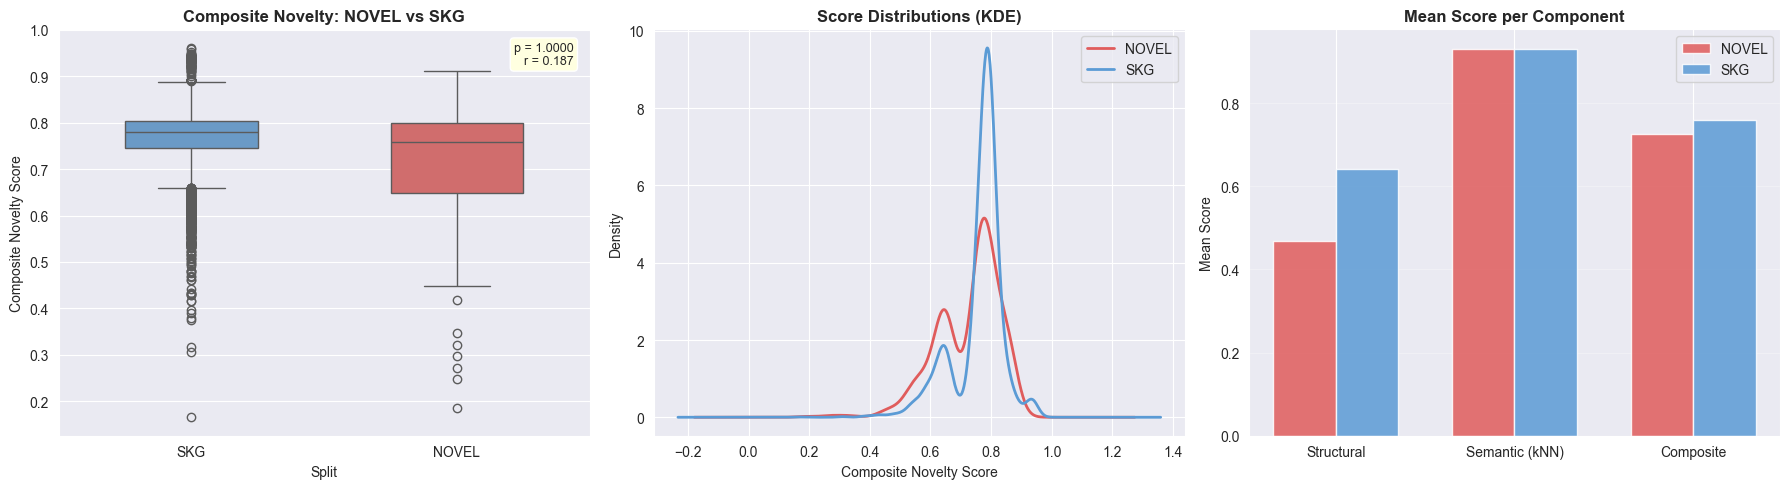

Saved: baseline_validation.png


In [6]:
# Plots
palette = {'NOVEL': '#E05C5C', 'SKG': '#5B9BD5'}
order   = ['SKG', 'NOVEL']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Boxplot ---
sns.boxplot(data=df, x='split', y='composite_novelty',
            order=order, palette=palette, ax=axes[0], width=0.5)
axes[0].set_title('Composite Novelty: NOVEL vs SKG', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Split')
axes[0].set_ylabel('Composite Novelty Score')
axes[0].annotate(f'p = {p_value:.4f}\nr = {effect_size:.3f}',
                 xy=(0.97, 0.97), xycoords='axes fraction',
                 ha='right', va='top', fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow'))

# KDE
for split, color in palette.items():
    df[df['split'] == split]['composite_novelty'].dropna().plot.kde(
        ax=axes[1], label=split, color=color, linewidth=2)
axes[1].set_title('Score Distributions (KDE)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Composite Novelty Score')
axes[1].legend()

# Per-component bar chart
components  = ['structural_novelty', 'semantic_knn', 'composite_novelty']
comp_labels = ['Structural', 'Semantic (kNN)', 'Composite']
means = df.groupby('split')[components].mean()

x = np.arange(len(comp_labels))
w = 0.35
axes[2].bar(x - w/2, means.loc['NOVEL'], w, label='NOVEL', color='#E05C5C', alpha=0.85)
axes[2].bar(x + w/2, means.loc['SKG'],   w, label='SKG',   color='#5B9BD5', alpha=0.85)
axes[2].set_xticks(x)
axes[2].set_xticklabels(comp_labels)
axes[2].set_ylabel('Mean Score')
axes[2].set_title('Mean Score per Component', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("../../outputs/visuals/" + 'baseline_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: baseline_validation.png")

In [7]:
# Save results CSV
results = pd.DataFrame([{
    'novel_mean'  : round(novel_scores.mean(), 4),
    'skg_mean'    : round(skg_scores.mean(), 4),
    'mean_gap'    : round(novel_scores.mean() - skg_scores.mean(), 4),
    'u_stat'      : round(u_stat, 2),
    'p_value'     : round(p_value, 6),
    'effect_size' : round(effect_size, 4),
    'significant' : p_value < 0.05
}])
results.to_csv(OUT_DIR + 'baseline_validation_results.csv', index=False)
print("Saved: baseline_validation_results.csv")
print(results.to_string(index=False))

Saved: baseline_validation_results.csv
 novel_mean  skg_mean  mean_gap   u_stat  p_value  effect_size  significant
     0.7255    0.7594   -0.0338 902864.5      1.0       0.1873        False
